# Customer Churn Analysis
### Telecom Company — End-to-End ML Project

**Goal:** Predict which customers are likely to churn and understand the key drivers behind it.

**Dataset:** IBM Telco Customer Churn — 7,043 customers, 21 features

**Steps:**
1. Data Loading & Exploration
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training & Evaluation
6. Insights & Recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv('/home/jovyan/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Dataset Info:")
print(df.info())
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")
print(f"\nChurn percentage:\n{df['Churn'].value_counts(normalize=True)*100}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [4]:
# Fix TotalCharges (it has spaces instead of NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID (not useful for modeling)
df.drop('customerID', axis=1, inplace=True)

# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Cleaning done!")
print(f"Missing values after cleaning:\n{df.isnull().sum().sum()}")

Cleaning done!
Missing values after cleaning:
0


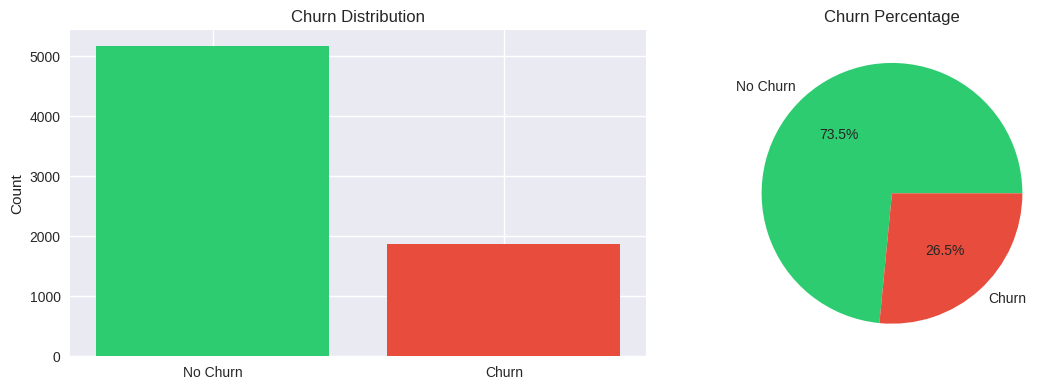

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn count
axes[0].bar(['No Churn', 'Churn'], df['Churn'].value_counts(), color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')

# Churn percentage pie
axes[1].pie(df['Churn'].value_counts(), labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn Percentage')

plt.tight_layout()
plt.savefig('/home/jovyan/work/churn_distribution.png', dpi=150)
plt.show()

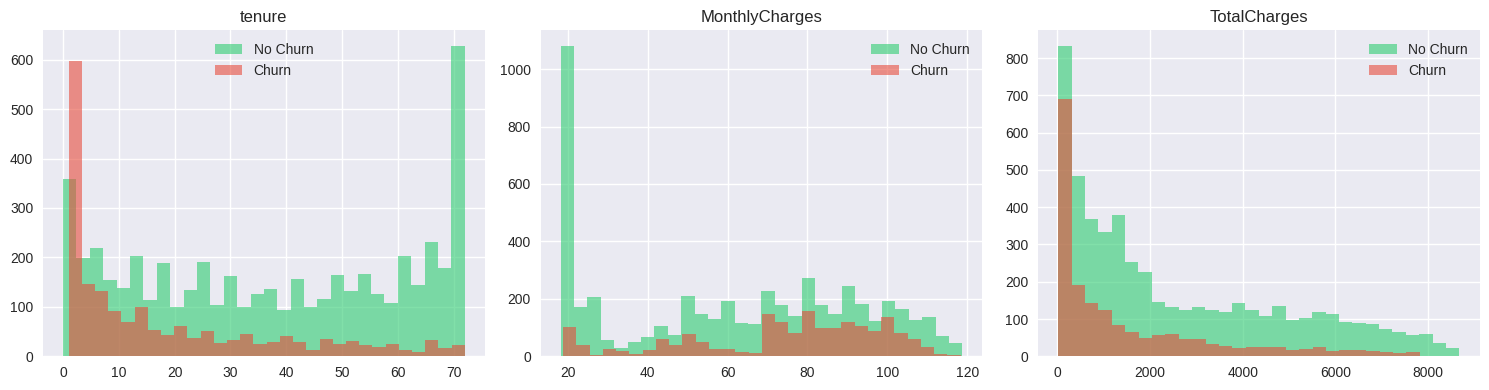

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    ax.hist(df[df['Churn']==0][col], alpha=0.6, label='No Churn', color='#2ecc71', bins=30)
    ax.hist(df[df['Churn']==1][col], alpha=0.6, label='Churn', color='#e74c3c', bins=30)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.savefig('/home/jovyan/work/numerical_features.png', dpi=150)
plt.show()

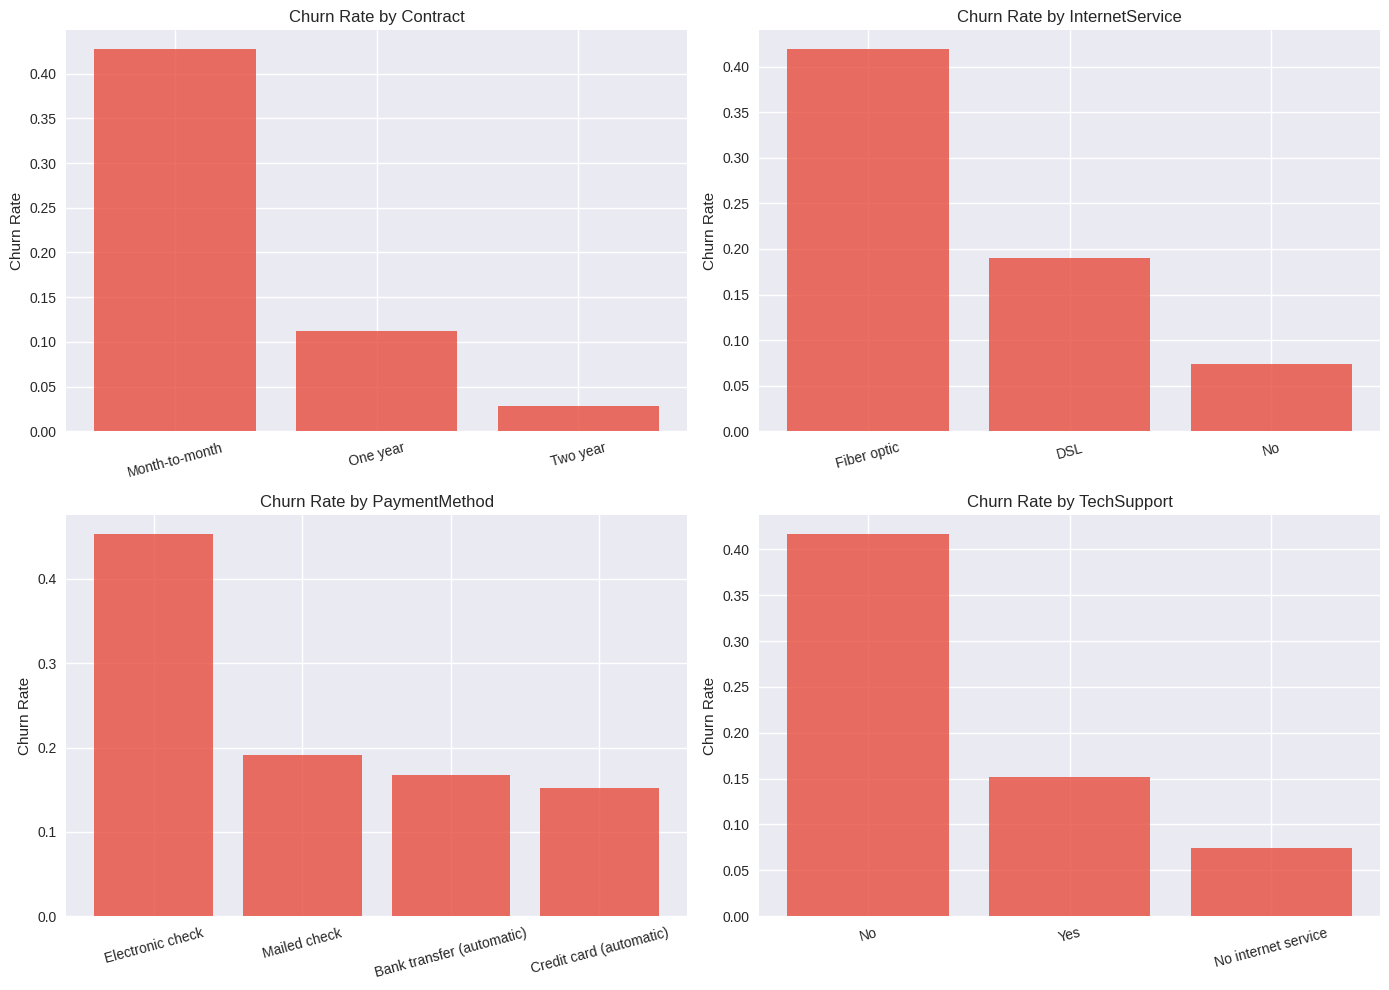

In [7]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    ax.bar(churn_rate.index, churn_rate.values, color='#e74c3c', alpha=0.8)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('/home/jovyan/work/categorical_features.png', dpi=150)
plt.show()

In [8]:
# Tenure groups
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,60,72],
                             labels=['0-1yr','1-2yr','2-4yr','4-5yr','5-6yr'])

# High value customer flag
df['high_value'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

# Number of services subscribed
service_cols = ['PhoneService','MultipleLines','InternetService',
                'OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']
df['num_services'] = df[service_cols].apply(
    lambda x: x.isin(['Yes','Fiber optic','DSL']).sum(), axis=1)

print("New features created!")
print(df[['tenure_group','high_value','num_services']].head())

New features created!
  tenure_group  high_value  num_services
0        0-1yr           0             2
1        2-4yr           0             4
2        0-1yr           0             4
3        2-4yr           0             4
4        0-1yr           1             2


In [9]:
df_model = df.copy()

# Drop tenure_group (we keep tenure as numeric)
df_model.drop('tenure_group', axis=1, inplace=True)

# Encode all object columns
le = LabelEncoder()
cat_columns = df_model.select_dtypes(include='object').columns

for col in cat_columns:
    df_model[col] = le.fit_transform(df_model[col])

print("Encoding done!")
print(df_model.dtypes)

Encoding done!
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
high_value            int64
num_services          int64
dtype: object


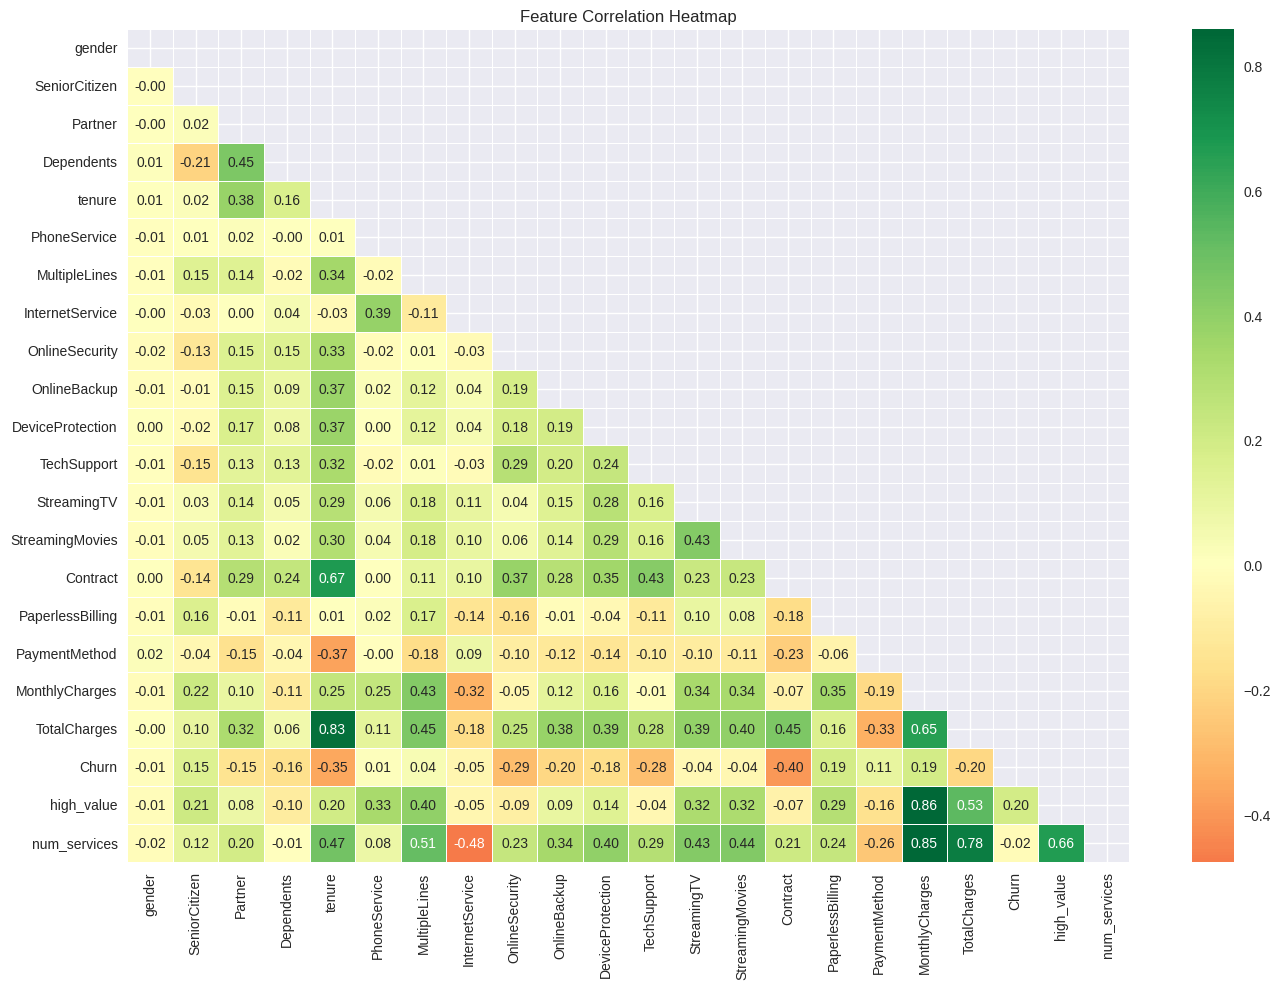

In [10]:
plt.figure(figsize=(14, 10))
corr = df_model.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('/home/jovyan/work/correlation_heatmap.png', dpi=150)
plt.show()

In [11]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Churn rate in train: {y_train.mean():.2%}")
print(f"Churn rate in test: {y_test.mean():.2%}")

Train size: (5634, 21)
Test size: (1409, 21)
Churn rate in train: 26.54%
Churn rate in test: 26.54%


In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob, 'auc': auc}
    print(f"\n{name} — AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))


Logistic Regression — AUC: 0.8397
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Random Forest — AUC: 0.8191
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409


Gradient Boosting — AUC: 0.8435
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.

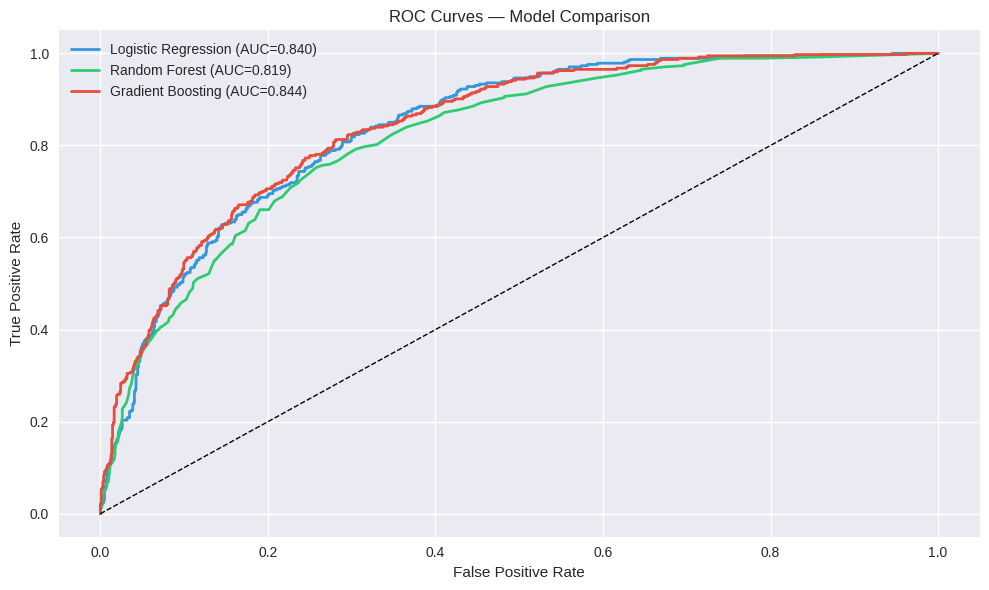

In [13]:
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color, lw=2)

plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('/home/jovyan/work/roc_curves.png', dpi=150)
plt.show()

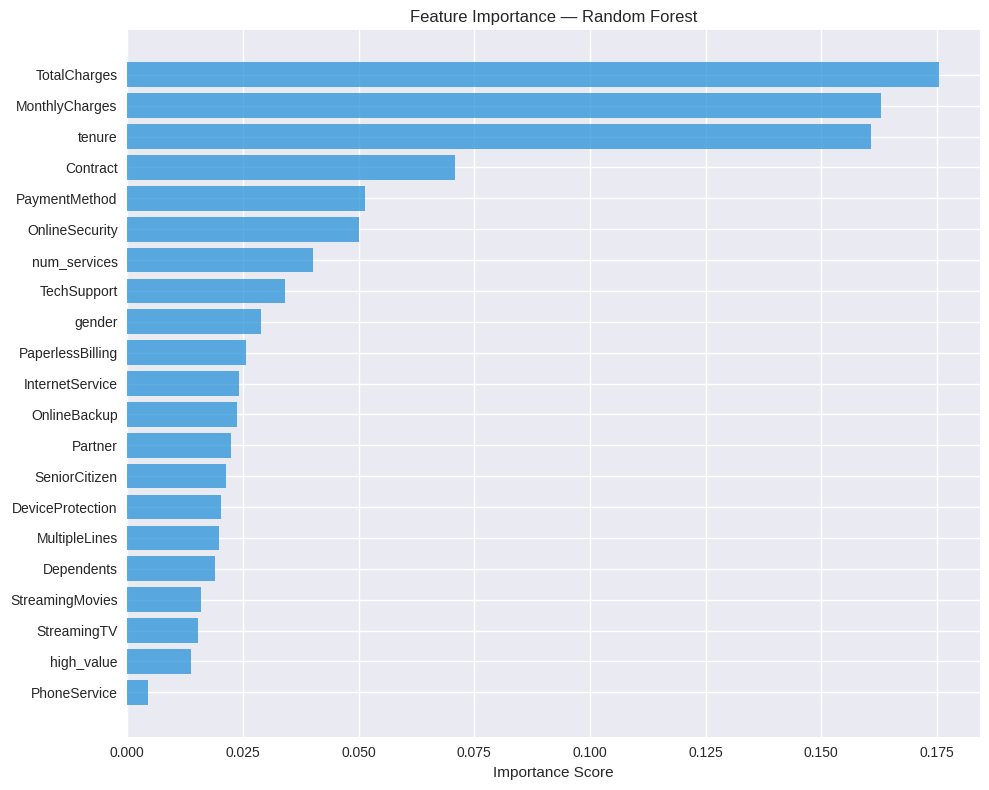

In [14]:
rf_model = results['Random Forest']['model']
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'], color='#3498db', alpha=0.8)
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('/home/jovyan/work/feature_importance.png', dpi=150)
plt.show()

In [15]:
import joblib
import os

os.makedirs('/home/jovyan/work/artifacts', exist_ok=True)

best_model = results['Gradient Boosting']['model']
joblib.dump(best_model, '/home/jovyan/work/artifacts/churn_model.pkl')
joblib.dump(scaler, '/home/jovyan/work/artifacts/scaler.pkl')
joblib.dump(list(X.columns), '/home/jovyan/work/artifacts/features.pkl')

print("Model saved successfully!")
print(f"Best AUC: {results['Gradient Boosting']['auc']:.4f}")

Model saved successfully!
Best AUC: 0.8435
